In [3]:
%load_ext autoreload
%autoreload 2

# 1) Clustering de datos
a) Implementar el algoritmo K-means y determinar la cantidad de clusters con el método de “ganancias decrecientes” (graficar L vs. K, y elegir un valor K donde al aumentar K deje de reducir significativamente L, donde L es la suma de las distancias). Graficar el conjunto de datos xi mostrando a qué cluster pertenece cada dato (usando colores/marcadores distintos para cada cluster) y también mostrar el centroide de cada cluster.

b) Implementar el algoritmo Gaussian Mixture Model (GMM) y realizar la misma tarea que en el inciso anterior. Recuerde que puede inicializar la optimización de GMM con una corrida de K-means.

c) Implementar el algoritmo DBSCAN y aplicarlo al conjunto de datos. Explorar el efecto de variar los parámetros ϵ (radio de la vecindad) y K (mínimo número de puntos en una zona densa). Luego, elegir una combinación razonable de ϵ y K y graficar los datos mostrando a qué cluster pertenece cada uno, utilizando colores/marcadores distintos para cada cluster/ruido.

In [ ]:
import sys
sys.path.append('../src')
from kmeans import *
from gmm_implementation import *
from dbscan import *
from vae import *
from utils import *
from data_splitting import *
from pca import *

Loading data...
Original data shape: (5000, 3)
Data range: [nan, nan]
Any NaN in data: True


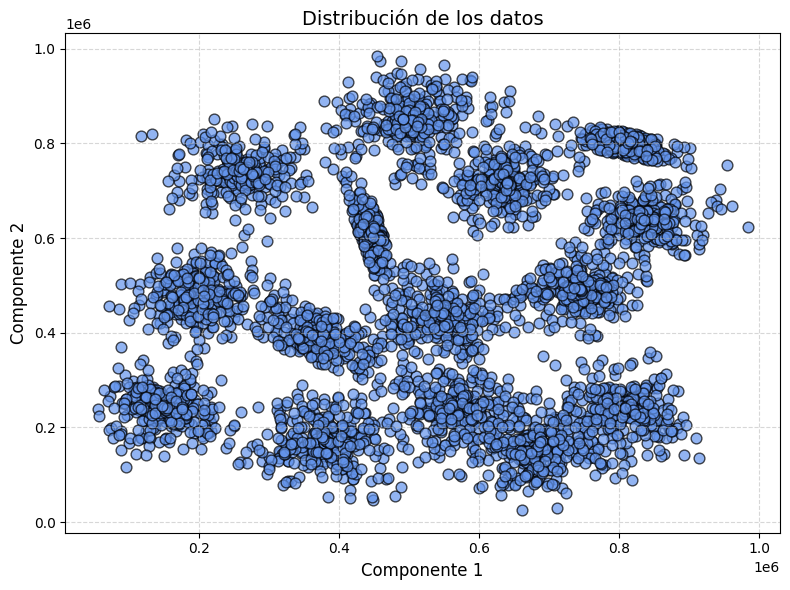


Statistics of NaN values:
Column 0: 1 NaN values
Column 1: 1 NaN values
Total NaN values in dataset: 2

Any NaN values after imputation?: False
Processed data shape: (5000, 2)
Processed data range: [-2.129535818086965, 2.169423347333603]

Finding best K...

Trying k=1
Initial total distance: 9271.902552002128
Run 1: distance = 6642.14
Initial total distance: 10320.932047276803
Run 2: distance = 6642.14
Initial total distance: 9223.538340436433
Run 3: distance = 6642.14
Initial total distance: 8980.349358190335
Run 4: distance = 6642.14
Initial total distance: 9821.918874016363
Run 5: distance = 6642.14
Best distance for k=1: 6642.14

Trying k=2
Initial total distance: 5862.0384227454615
Run 1: distance = 4948.48
Initial total distance: 6838.786841683397
Run 2: distance = 4948.45
Initial total distance: 6074.020894204246
Run 3: distance = 5037.32
Initial total distance: 9286.388184786352
Run 4: distance = 5187.31
Initial total distance: 5996.055610012407
Run 5: distance = 5129.35
Best 

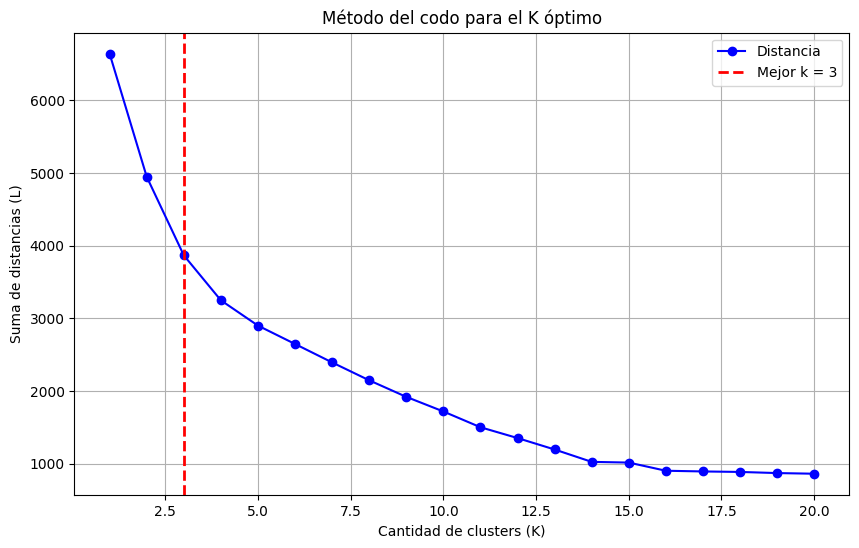

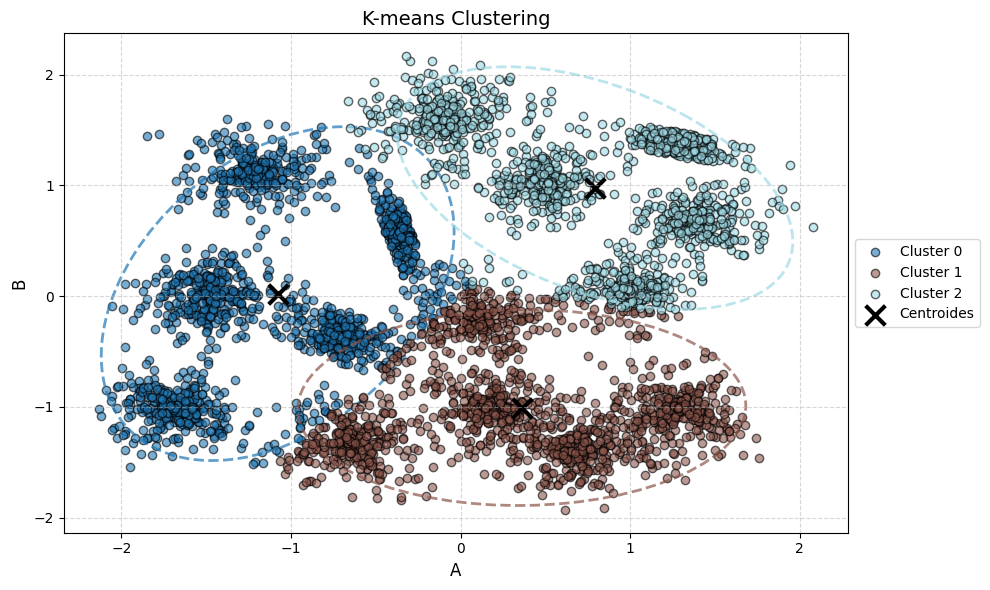


Final sum of distances: 3867.37
Clustering completed successfully!


In [ ]:
# K-Means clustering
data, labels, centroids, stats = load_kmeans_results()

if data is None:
    print("No previous results found. Running K-means clustering...")
    run_kmeans_clustering()
else:
    print("\nPrevious K-means results found!")
    print("Parameters used:")
    print(f"K = {stats['k']}")
    print(f"Final distance = {stats['final_distance']}")
    
    plot_clusters(data, labels, centroids)

Loading data...
Original data shape: (5000, 3)
Data range: [nan, nan]
Any NaN in data: True


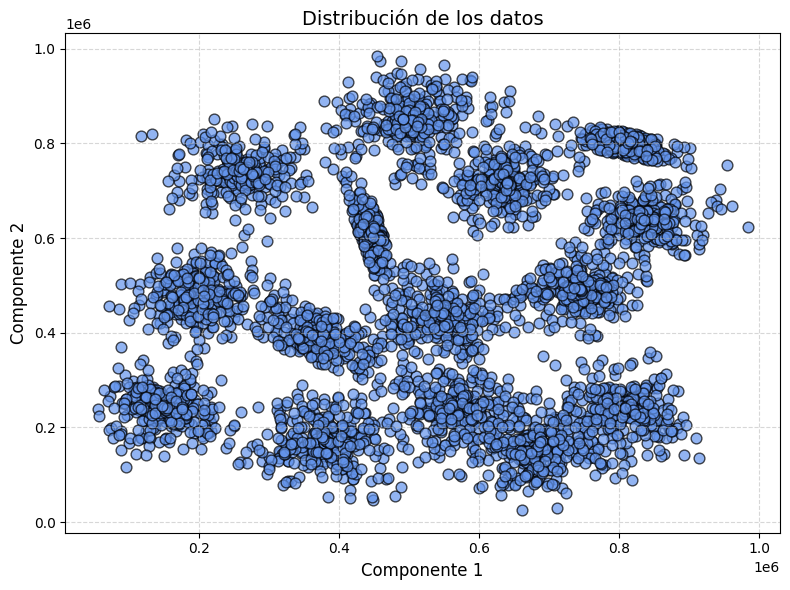


Statistics of NaN values:
Column 0: 1 NaN values
Column 1: 1 NaN values
Total NaN values in dataset: 2

Any NaN values after imputation?: False
Processed data shape: (5000, 2)
Processed data range: [-2.129535818086965, 2.169423347333603]

Finding best K...

Trying k=1
Initial total distance: 10304.601647732434
Run 1: silhouette score = -1.0000
Initial total distance: 10161.390299869041
Run 2: silhouette score = -1.0000
Initial total distance: 10704.120827446866
Run 3: silhouette score = -1.0000
Initial total distance: 7162.1708926367655
Run 4: silhouette score = -1.0000
Initial total distance: 9436.698844208884
Run 5: silhouette score = -1.0000
Best silhouette score for k=1: -1.0000

Trying k=2
Initial total distance: 5535.10497918685
Run 1: silhouette score = 0.3483
Initial total distance: 5818.429754558061
Run 2: silhouette score = 0.3483
Initial total distance: 8266.330132374289
Run 3: silhouette score = 0.3483
Initial total distance: 6018.022307774578
Run 4: silhouette score = 0.3

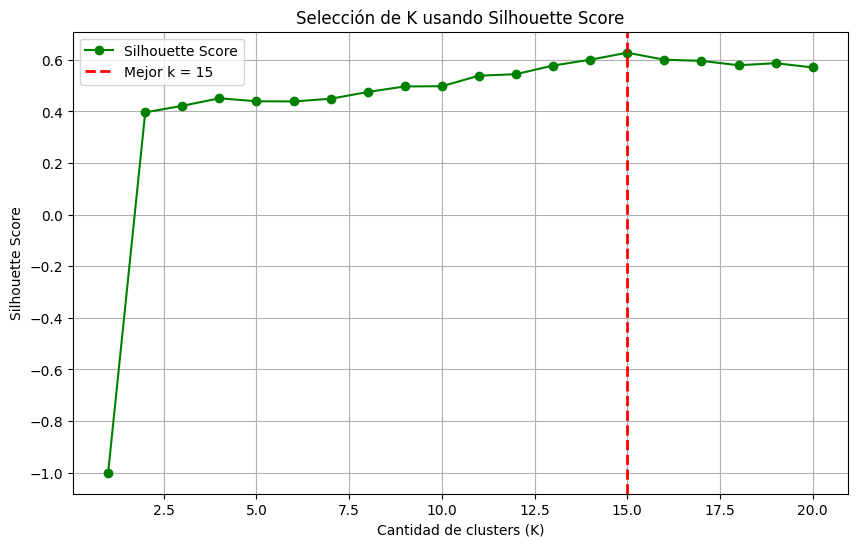

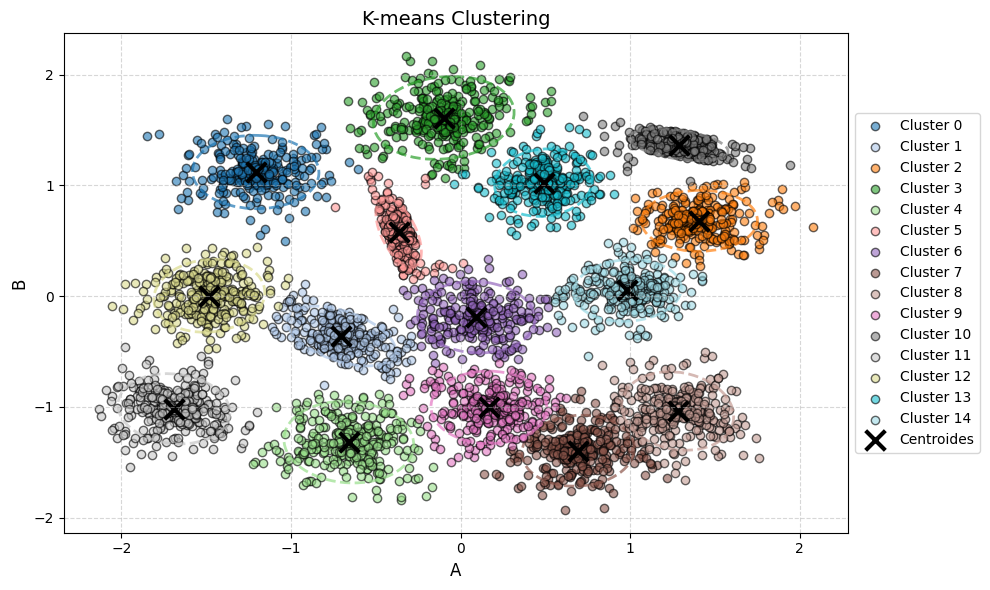


Final sum of distances: 0.63
Clustering completed successfully!


In [ ]:
# K-Means clustering (Silhouette)
data, labels, centroids, stats = load_kmeans_results(input_dir='../results_kmeans_silhouette')

if data is None:
    print("No previous results found. Running K-means clustering...")
    run_kmeans_clustering(silhouette=True)
else:
    print("\nPrevious K-means results found!")
    print("Parameters used:")
    print(f"K = {stats['k']}")
    print(f"Final distance = {stats['final_distance']}")
    
    plot_clusters(data, labels, centroids)

Loading data...
Original data shape: (5000, 3)
Data range: [nan, nan]
Any NaN in data: True

Statistics of NaN values:
Column 0: 1 NaN values
Column 1: 1 NaN values
Total NaN values in dataset: 2

Any NaN values after imputation?: False
Processed data shape: (5000, 2)

Finding best K...

Trying k=1
Run 1/3
Initial total distance: 9805.523915062175
Iter 1: Log-likelihood = -14145.0201
Iter 2: Log-likelihood = -14145.0201
Convergencia alcanzada.
Run 1: log-likelihood = -14145.020115993717
Run 2/3
Initial total distance: 6785.983628954876
Iter 1: Log-likelihood = -14145.0201
Iter 2: Log-likelihood = -14145.0201
Convergencia alcanzada.
Run 2: log-likelihood = -14145.020115993717
Run 3/3
Initial total distance: 6644.89840752634
Iter 1: Log-likelihood = -14145.0201
Iter 2: Log-likelihood = -14145.0201
Convergencia alcanzada.
Run 3: log-likelihood = -14145.020115993717
Best log-likelihood for k=1: -14145.020115993717

Trying k=2
Run 1/3
Initial total distance: 5183.712416787472
Iter 1: Log-li

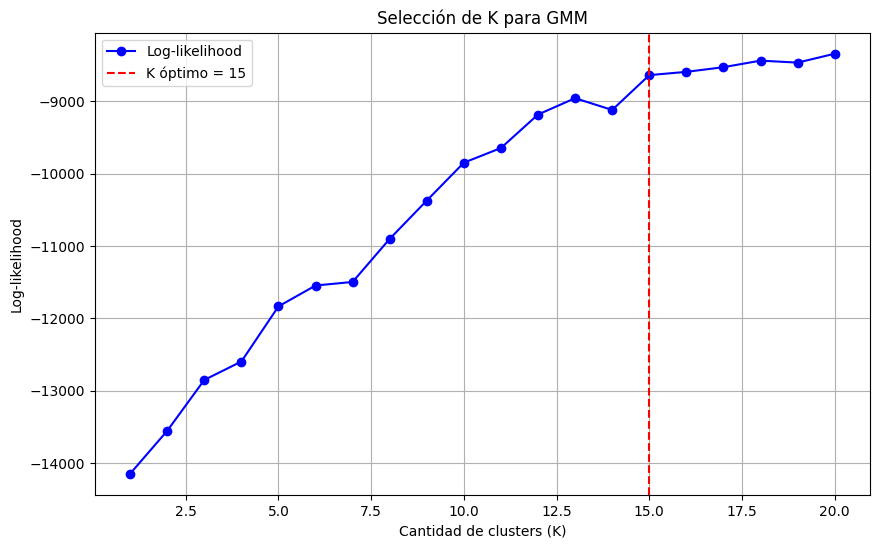

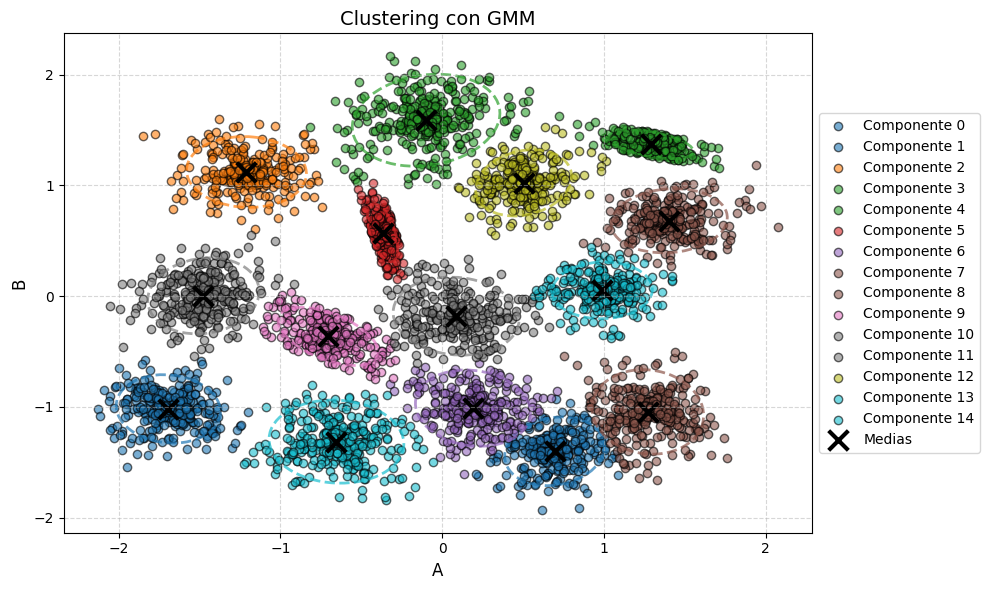


Final log-likelihood: -8640.80576969576
Clustering completed successfully!


In [ ]:
# GMM clustering
data, responsibilities, means, covariances, stats, K_values, log_likelihoods = load_gmm_results()

if data is None:
    print("No previous results found. Running GMM clustering...")
    run_gmm_clustering()
else:
    print("\nPrevious GMM results found!")
    print("Parameters used:")
    print(f"K = {stats['k']}")
    print(f"Log-likelihood = {stats['log_likelihood']}")
    
    plot_gmm_clusters(data, responsibilities, means, covariances)
    plot_gmm_elbow_from_results(K_values, log_likelihoods, best_k=stats['k'])


Loaded clustering results from ../results/
Dataset shape: (5000, 2)
Number of clusters: 15
Number of noise points: 949

Previous DBScan results found!
Parameters used:
eps = 0.10
min_points = 17


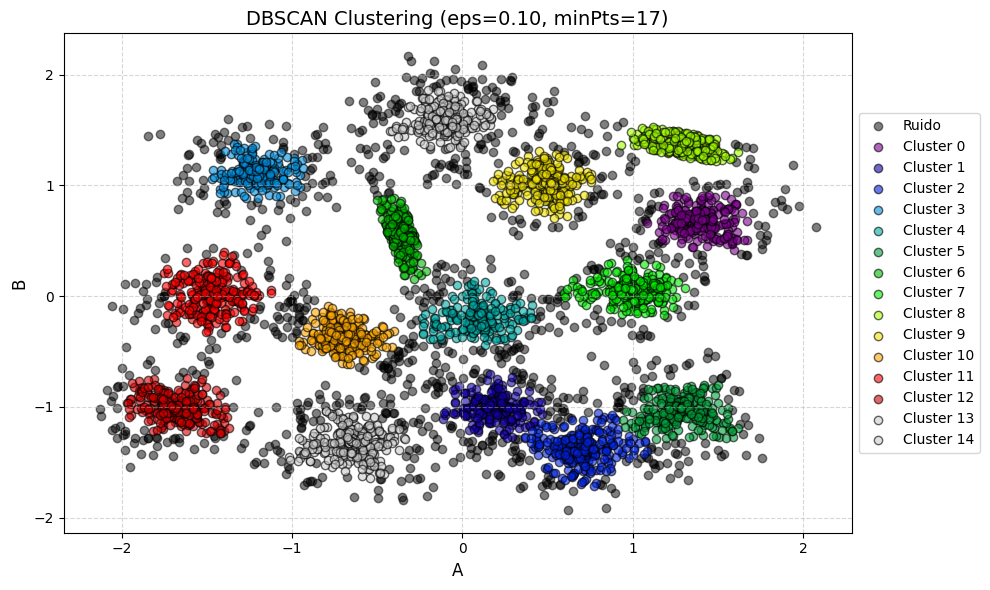

In [ ]:
# DBSCAN clustering
data, labels, stats = load_results()

if data is None:
    print("No previous results found. Running DBScan...")
    run_dbscan_clustering()

else:
    print("\nPrevious DBScan results found!")
    print("Parameters used:")
    print(f"eps = {stats['eps']:.2f}")
    print(f"min_points = {stats['min_points']}")
    
    plot_clusters_dbscan(data, labels, f'DBSCAN Clustering (eps={stats["eps"]:.2f}, minPts={stats["min_points"]})')

# 2) Reducción de dimensionalidad. 
Este problema se basará en el dataset MNIST_dataset.csv, que contiene representaciones tabulares de imágenes de dígitos del 0 al 9. Originalmente, cada imagen tiene una resolución de 28x28 píxeles en escala de grises. En este conjunto de datos, cada imagen se representa como una fila de 784 (28x28) valores, donde cada valor representa la intensidad de gris de un píxel en la imagen.

a) Implementar Principal Component Analysis (PCA) y aplicarlo al conjunto de datos. Graficar cómo varía el error cuadrático medio de reconstrucción sobre el conjunto de datos en función de la cantidad de componentes principales utilizadas.

b) Seleccionar la cantidad de componentes principales que considere adecuada y justifique la elección. Usando dicha cantidad de componentes, graficar las imagenes de los digitos originales y reconstruidos para las primeras 10 muestras del dataset.

c) OPCIONAL: Entrenar un modelo de autoencoder variacional (VAE) utilizando la librería PyTorch para armar y entrenar las redes neuronales involucradas (la red de encoder y la de decoder). Recuerde dividir el conjunto de datos en dos subconjuntos: entrenamiento y validación. El subconjunto de entrenamiento se empleará para entrenar el VAE, mientras que el de validación servirá para ajustar los hiperparámetros y evaluar el error de reconstrucción. Una vez desarrollado el VAE, compare la calidad de las imágenes reconstruidas con las obtenidas mediante PCA en el inciso anterior, utilizando 10 imagenes tomadas aleatoriamente del conjunto de validación del VAE


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

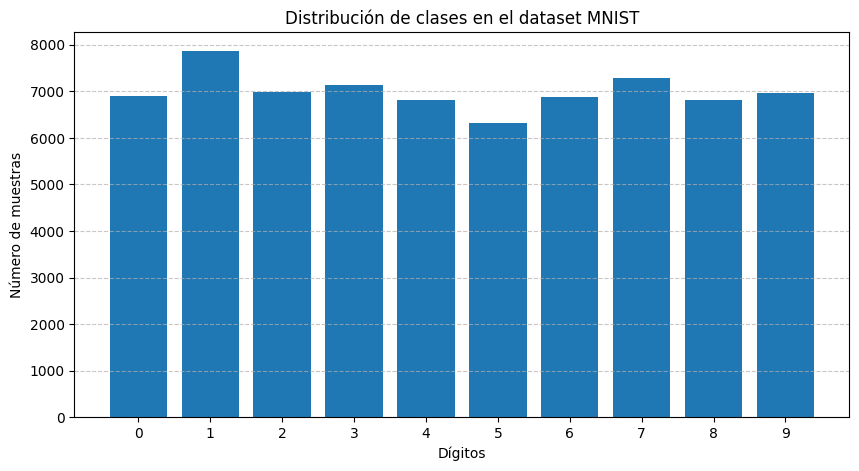

In [ ]:
X, labels = load_data_reduce_dimensionality()

In [ ]:
# Normalice and center the data
X = X/255
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# PCA with SVD
U, S, Vt, explained_variance, explained_variance_ratio, cumulative_variance_ratio = pca_with_svd(X, X_centered)

In [ ]:
# Reconstruction error for different numbers of components
errors = []
components_range = range(1, 351, 5)

for k in components_range:
    X_proj = X_centered @ Vt[:k].T
    X_reconstructed = X_proj @ Vt[:k] + X_mean
    X_reconstructed = np.clip(X_reconstructed, 0, 1)

    mse = np.mean((X - X_reconstructed) ** 2)
    errors.append(mse)

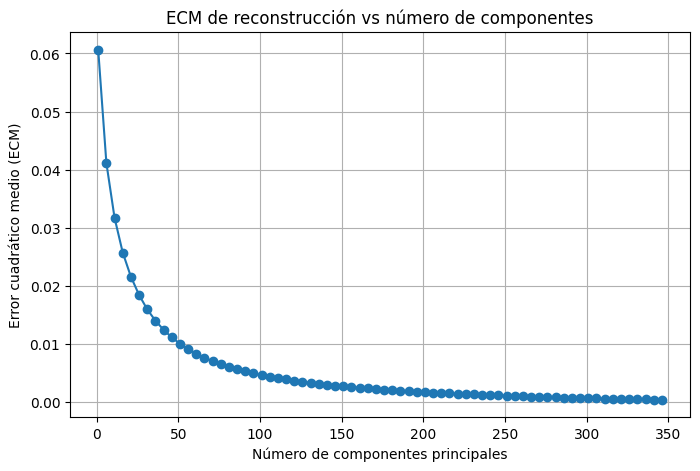

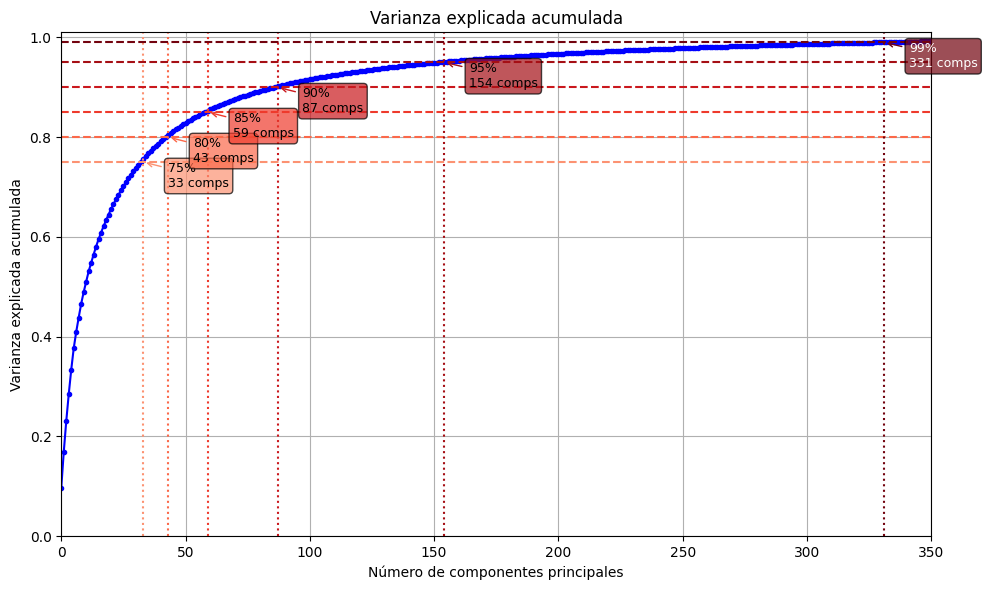

In [ ]:
# ECM vs components
plot_error_vs_components(components_range, errors)

# Plot cumulative explained variance with multiple thresholds
thresholds = [0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
components_for_thresholds = plot_cumulative_variance(cumulative_variance_ratio, thresholds)

Umbral de varianza 75%: 33 componentes, ECM: 0.0152


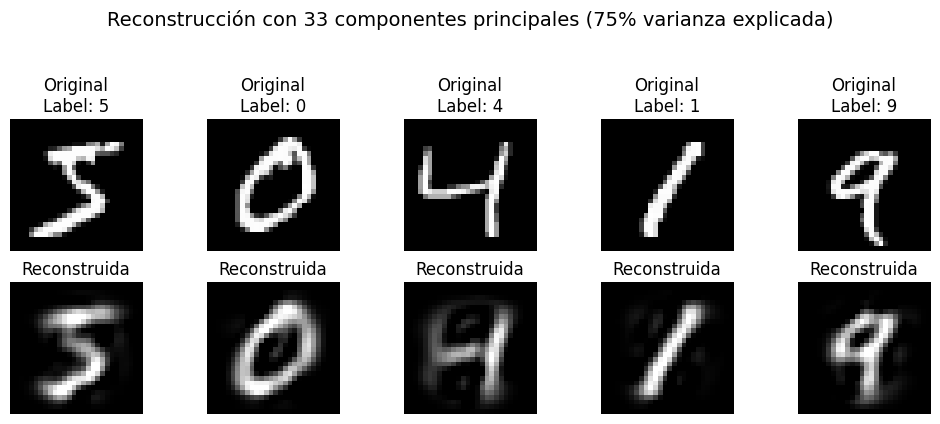

Umbral de varianza 80%: 43 componentes, ECM: 0.0119


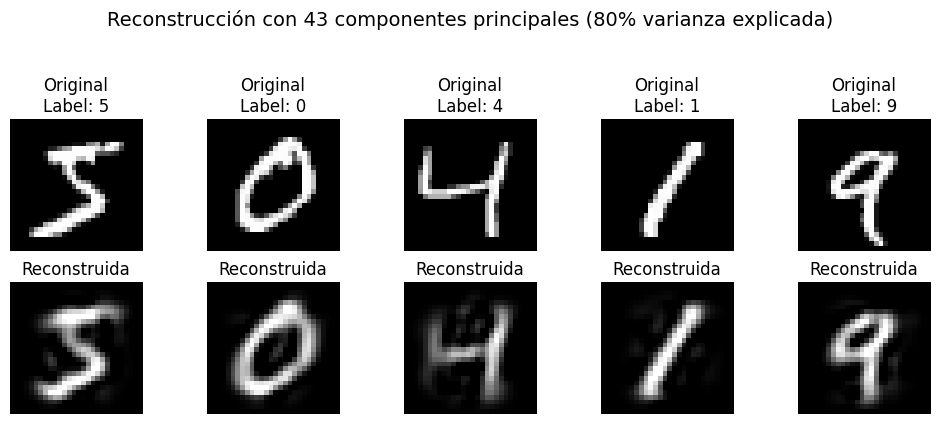

Umbral de varianza 85%: 59 componentes, ECM: 0.0087


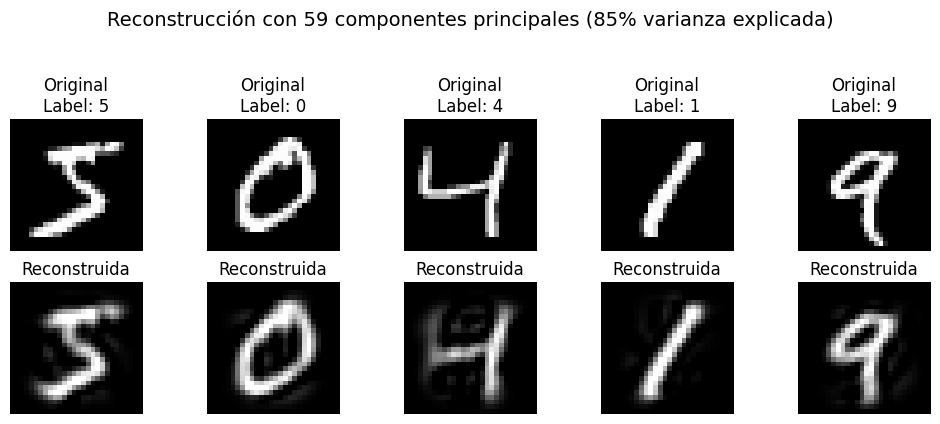

Umbral de varianza 90%: 87 componentes, ECM: 0.0056


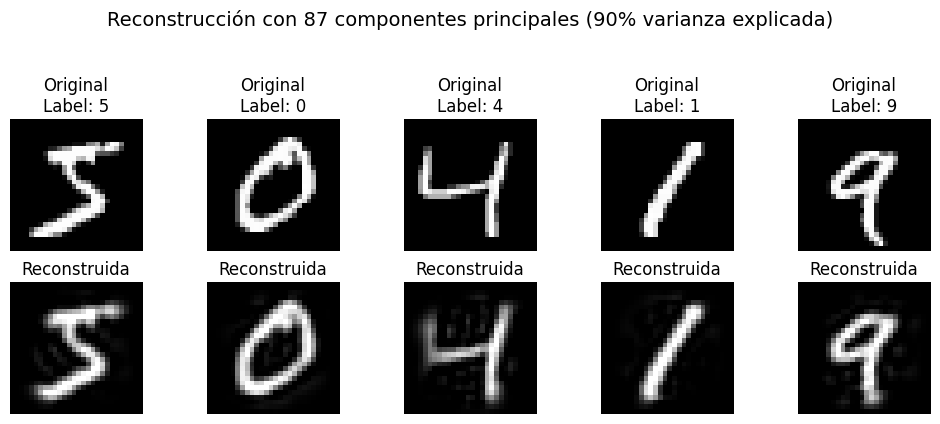

Umbral de varianza 95%: 154 componentes, ECM: 0.0027


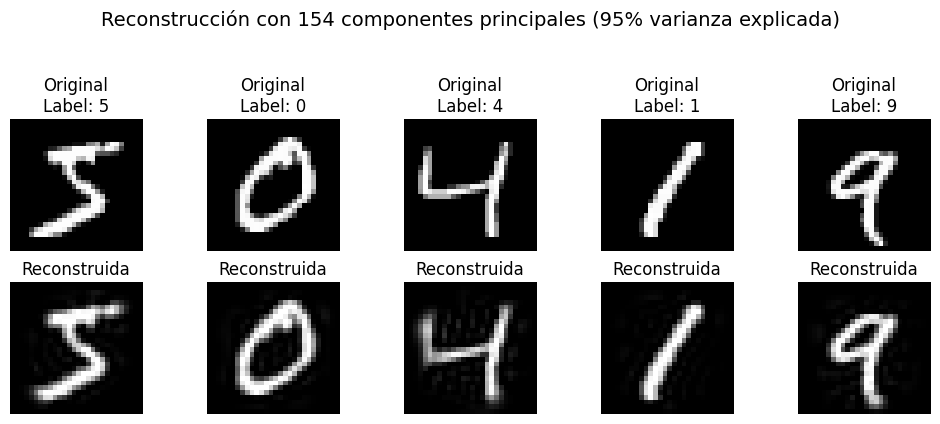

Umbral de varianza 99%: 331 componentes, ECM: 0.0005


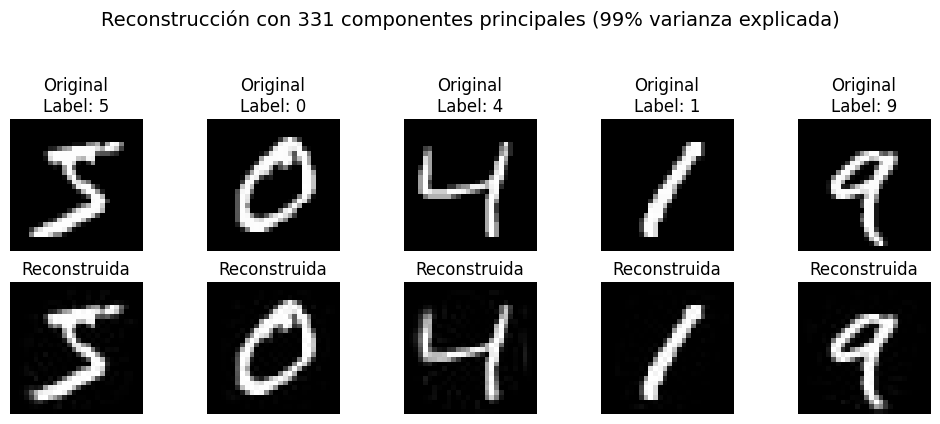

In [ ]:
# analyze the reconstruction with the different variances explained
for t, k in components_for_thresholds.items():
    X_proj = X_centered @ Vt[:k].T
    X_rec = X_proj @ Vt[:k] + X_mean
    X_rec = np.clip(X_rec, 0, 1)

    mse = np.mean((X - X_rec) ** 2)
    print(f"Umbral de varianza {int(t*100)}%: {k} componentes, ECM: {mse:.4f}")
    plot_reconstructions(X[:5], X_rec[:5], n=5, labels=labels[:5] if labels is not None else None,
                     title=f"Reconstrucción con {k} componentes principales ({int(t*100)}% varianza explicada)")

Umbral de varianza 80%: 43 componentes, ECM: 0.0119


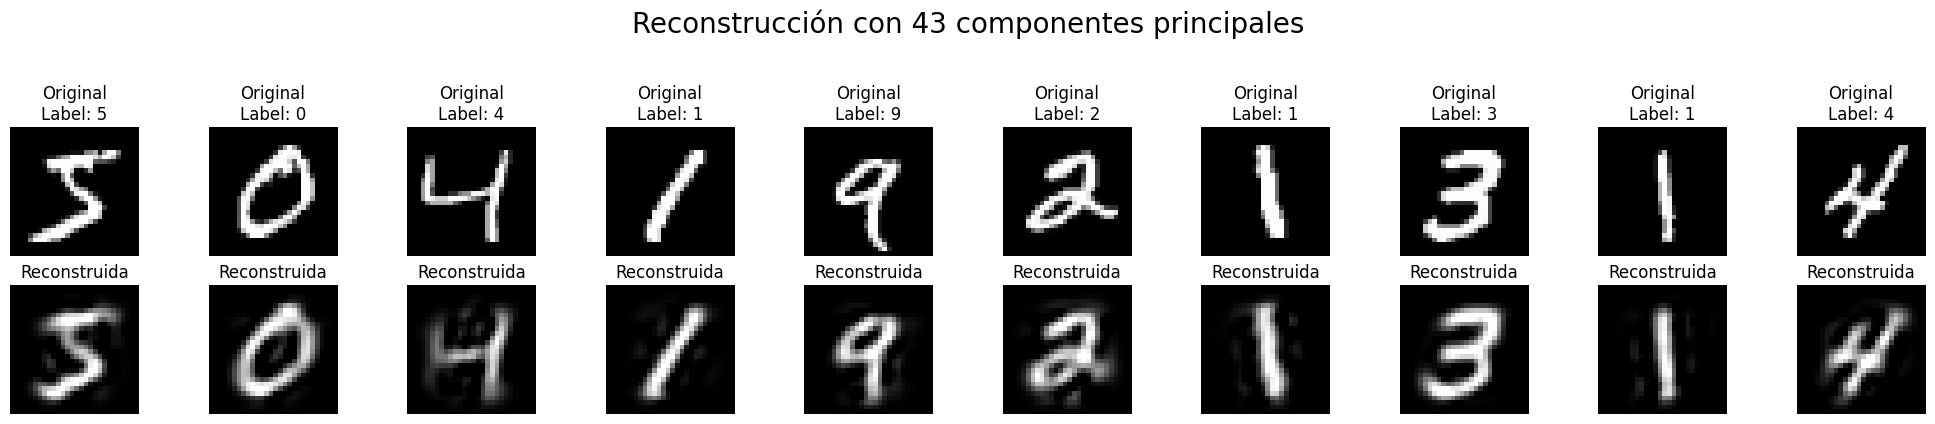

In [ ]:
# original images vs reconstructed images
X_proj_80 = X_centered @ Vt[:components_for_thresholds[0.80]].T
X_rec_80 = X_proj_80 @ Vt[:components_for_thresholds[0.80]] + X_mean
X_rec_80 = np.clip(X_rec_80, 0, 1)

mse = np.mean((X - X_rec_80) ** 2)
print(f"Umbral de varianza 80%: {components_for_thresholds[0.80]} componentes, ECM: {mse:.4f}")

plot_reconstructions(X[:10], X_rec_80[:10], n=10, labels=labels[:10] if labels is not None else None,
                     title=f"Reconstrucción con {components_for_thresholds[0.80]} componentes principales",
                     title_size=20)

In [ ]:
X_train, y_train, X_val, y_val = stratified_train_val_split(X, labels)
X_mean = X_train.mean(axis=0)
X_centered = X_train - X_mean

torch.manual_seed(42)
latent_dim = 20
batch_size = 128
epochs = 100
lr = 1e-3

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_tensor), batch_size=batch_size)

In [ ]:
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)
train_vae(vae, train_loader, val_loader, epochs, optimizer)

Epoch 1: Train Loss = 9318056.11, Val Loss = 1811899.81
Epoch 2: Train Loss = 6847636.31, Val Loss = 1645357.74
Epoch 3: Train Loss = 6432571.18, Val Loss = 1584467.88
Epoch 4: Train Loss = 6261893.11, Val Loss = 1556657.86
Epoch 5: Train Loss = 6161079.52, Val Loss = 1542895.99
Epoch 6: Train Loss = 6097701.21, Val Loss = 1523465.28
Epoch 7: Train Loss = 6045828.14, Val Loss = 1509498.76
Epoch 8: Train Loss = 6012423.18, Val Loss = 1505596.11
Epoch 9: Train Loss = 5981000.34, Val Loss = 1497276.31
Epoch 10: Train Loss = 5958928.00, Val Loss = 1495769.29
Epoch 11: Train Loss = 5937873.95, Val Loss = 1489561.77
Epoch 12: Train Loss = 5921040.58, Val Loss = 1486837.56
Epoch 13: Train Loss = 5902252.43, Val Loss = 1481422.25
Epoch 14: Train Loss = 5893508.92, Val Loss = 1480326.04
Epoch 15: Train Loss = 5878545.46, Val Loss = 1477381.81
Epoch 16: Train Loss = 5867004.01, Val Loss = 1474107.63
Epoch 17: Train Loss = 5859195.09, Val Loss = 1474509.41
Epoch 18: Train Loss = 5849759.19, Val L

ECM en validación - VAE: 0.010


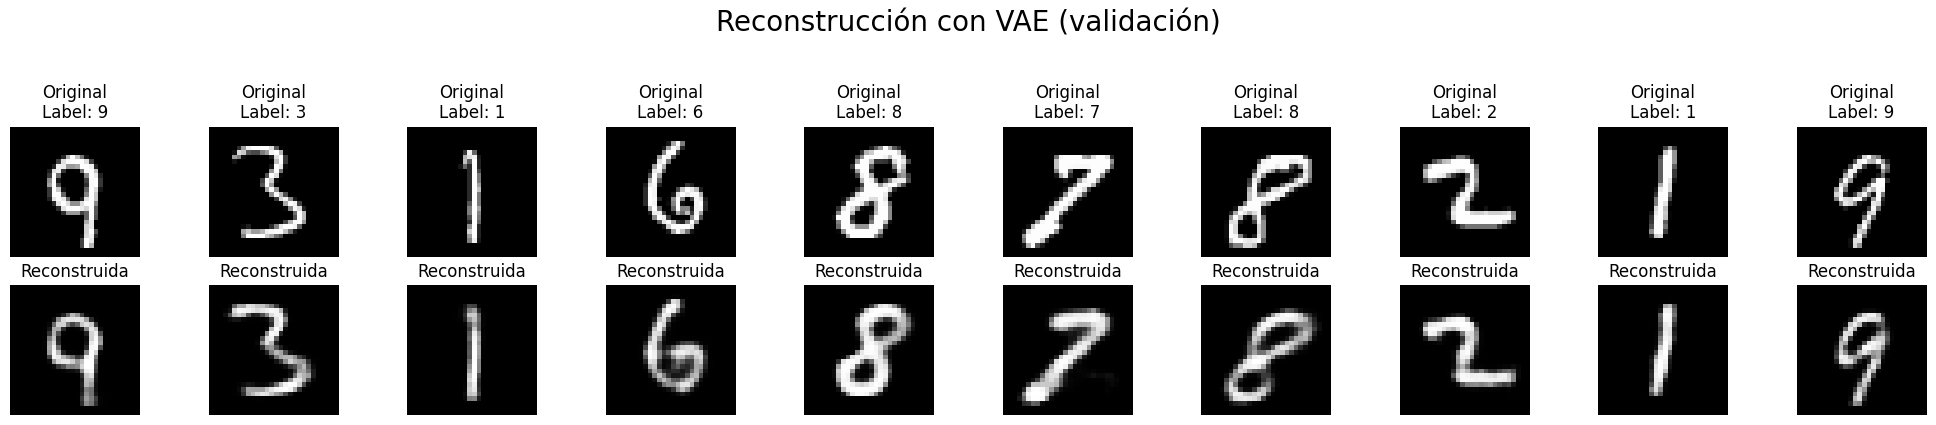

ECM en validación - PCA: 0.012


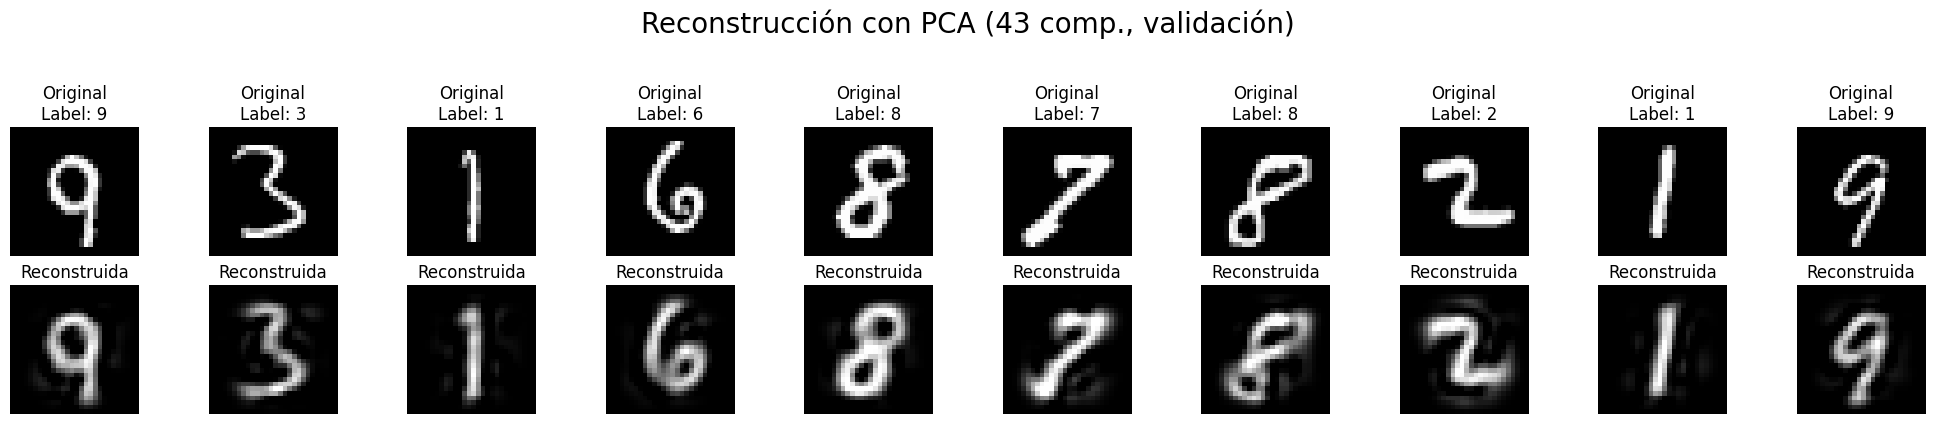

In [ ]:
indices = np.random.choice(len(X_val), size=10, replace=False)
X_val_sample = X_val[indices]
X_val_tensor_sample = torch.tensor(X_val_sample, dtype=torch.float32)

# VAE reconstruction
vae.eval()
with torch.no_grad():
    recon_vae, _, _ = vae(X_val_tensor_sample)
    X_val_rec_vae_np = recon_vae.cpu().numpy()

# PCA reconstruction (using already calculated Vt)
X_val_centered = X_val_sample - X_mean
X_val_proj_pca = X_val_centered @ Vt[:components_for_thresholds[0.80]].T
X_val_rec_pca = X_val_proj_pca @ Vt[:components_for_thresholds[0.80]] + X_mean
X_val_rec_pca = np.clip(X_val_rec_pca, 0, 1)

# ECM for 10 sample images
mse_pca = np.mean((X_val_sample - X_val_rec_pca) ** 2)
mse_vae = np.mean((X_val_sample - X_val_rec_vae_np) ** 2)

print(f"ECM en validación - VAE: {mse_vae:.3f}")
plot_reconstructions(
    X_val_sample, 
    recon_vae.cpu().numpy(), 
    n=10,
    labels=y_val[indices],
    title="Reconstrucción con VAE (validación)",
    title_size=20
)

print(f"ECM en validación - PCA: {mse_pca:.3f}")
plot_reconstructions(
    X_val_sample,
    X_val_rec_pca,
    n=10,
    labels=y_val[indices],
    title=f"Reconstrucción con PCA ({components_for_thresholds[0.80]} comp., validación)",
    title_size=20
)